In [1]:
print("helloworld")

helloworld


In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [76]:
df = pd.read_excel("opensky_flights.xlsx")
df.head()

,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,sensors,geo_altitude,squawk,spi,position_source
0,39de4f,TVF78UN,France,1.773126e+09,1773126279,9.2835,48.0849,11894.82,False,230.54,109.28,0.00,NaN,11811.00,660.0,False,0
1,4b1815,SWR2121,Switzerland,1.773126e+09,1773126264,8.5587,47.4536,365.76,True,0.00,5.62,NaN,NaN,NaN,1000.0,False,0
2,4b1817,SWR183B,Switzerland,1.773126e+09,1773126279,8.5510,47.4580,388.62,False,76.58,276.17,8.13,NaN,495.30,1000.0,False,0
3,4b1819,SWR47W,Switzerland,1.773126e+09,1773126279,7.4011,47.8098,5996.94,False,163.29,159.34,-7.80,NaN,6073.14,1000.0,False,0
4,80162d,AXB1032,India,1.773126e+09,1773126278,92.3102,25.5791,7620.00,False,196.12,141.18,0.00,NaN,7955.28,NaN,False,0


In [77]:
df.isnull().sum()

icao24                0
callsign            104
origin_country        0
time_position        43
last_contact          0
longitude            43
latitude             43
baro_altitude       547
on_ground             0
velocity              1
true_track            0
vertical_rate       540
sensors            4789
geo_altitude        610
squawk             1942
spi                   0
position_source       0
dtype: int64

In [97]:
df = df.dropna(subset=['velocity','baro_altitude','latitude','longitude'])
df = df.drop("sensors",axis=1)

In [98]:
df.head()

,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,...,squawk,spi,position_source,speed_category,flight_status,vertical_status,altitude_level,hemisphere,east_west,direction
0,39de4f,TVF78UN,France,1.773126e+09,1773126279,9.2835,48.0849,11894.82,False,230.54,...,660.0,False,0,medium,Flying,Level,High,North,East,North_East
1,4b1815,SWR2121,Switzerland,1.773126e+09,1773126264,8.5587,47.4536,365.76,True,0.00,...,1000.0,False,0,NaN,Grounded,Level,Low,North,East,North_East
2,4b1817,SWR183B,Switzerland,1.773126e+09,1773126279,8.5510,47.4580,388.62,False,76.58,...,1000.0,False,0,slow,Flying,Climbing,Low,North,East,North_East
3,4b1819,SWR47W,Switzerland,1.773126e+09,1773126279,7.4011,47.8098,5996.94,False,163.29,...,1000.0,False,0,medium,Flying,Descending,Medium,North,East,North_East
4,80162d,AXB1032,India,1.773126e+09,1773126278,92.3102,25.5791,7620.00,False,196.12,...,NaN,False,0,medium,Flying,Level,Medium,North,East,North_East


In [80]:
#feature enginnering

#calculating speed

df['speed_category'] = pd.cut(df['velocity'],bins=[0,150,300,600,1000],labels=['slow','medium','fast','very_fast'])
df[['speed_category','velocity']].head()


,speed_category,velocity
0,medium,230.54
1,NaN,0.00
2,slow,76.58
3,medium,163.29
4,medium,196.12


In [81]:
#aircraft status
df['flight_status'] = df['on_ground'].apply(
    lambda x: "Grounded" if x else "Flying"
)
df[['on_ground','flight_status']].head()

,on_ground,flight_status
0,False,Flying
1,True,Grounded
2,False,Flying
3,False,Flying
4,False,Flying


In [82]:
# climbing and descending
def vertical_status(rate):
    if rate > 0:
        return "Climbing"
    elif rate < 0:
        return "Descending"
    else:
        return "Level"

df['vertical_status'] = df['vertical_rate'].apply(vertical_status)
df['vertical_status'].head()


0         Level
1         Level
2      Climbing
3    Descending
4         Level
Name: vertical_status, dtype: str

In [83]:
#domain driven feature selection

#altitude level

df['altitude_level'] = pd.cut(
    df['baro_altitude'],
    bins=[0,3000,10000,30000,45000],
    labels=['Low','Medium','High','Cruise']
)
df['altitude_level'].head()


0      High
1       Low
2       Low
3    Medium
4    Medium
Name: altitude_level, dtype: category
Categories (4, str): ['Low' < 'Medium' < 'High' < 'Cruise']

In [84]:
#direction
df['hemisphere'] = df['latitude'].apply(lambda x: "North" if x >= 0 else "South")
df['east_west'] = df['longitude'].apply(lambda x: "East" if x >= 0 else "West")
df['direction'] = df['hemisphere'] + "_" + df['east_west']

In [85]:
df['direction'].head()

0    North_East
1    North_East
2    North_East
3    North_East
4    North_East
Name: direction, dtype: str

In [86]:
#feature lekage

df.head()

,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,...,squawk,spi,position_source,speed_category,flight_status,vertical_status,altitude_level,hemisphere,east_west,direction
0,39de4f,TVF78UN,France,1.773126e+09,1773126279,9.2835,48.0849,11894.82,False,230.54,...,660.0,False,0,medium,Flying,Level,High,North,East,North_East
1,4b1815,SWR2121,Switzerland,1.773126e+09,1773126264,8.5587,47.4536,365.76,True,0.00,...,1000.0,False,0,NaN,Grounded,Level,Low,North,East,North_East
2,4b1817,SWR183B,Switzerland,1.773126e+09,1773126279,8.5510,47.4580,388.62,False,76.58,...,1000.0,False,0,slow,Flying,Climbing,Low,North,East,North_East
3,4b1819,SWR47W,Switzerland,1.773126e+09,1773126279,7.4011,47.8098,5996.94,False,163.29,...,1000.0,False,0,medium,Flying,Descending,Medium,North,East,North_East
4,80162d,AXB1032,India,1.773126e+09,1773126278,92.3102,25.5791,7620.00,False,196.12,...,NaN,False,0,medium,Flying,Level,Medium,North,East,North_East


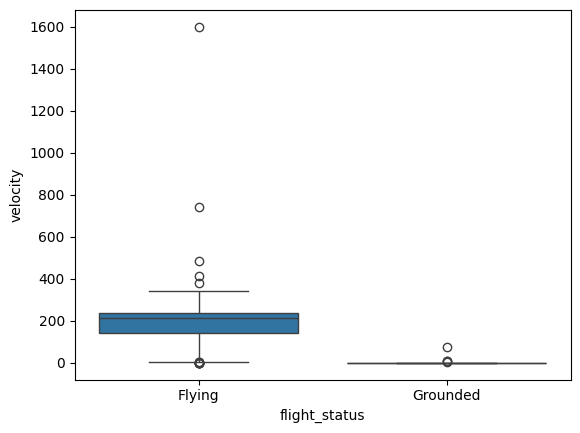

In [87]:
sns.boxplot(x='flight_status', y='velocity', data=df)
plt.show()

In [88]:
df['velocity'].skew()


np.float64(1.2417491515588908)

In [89]:
df.shape

(4238, 24)

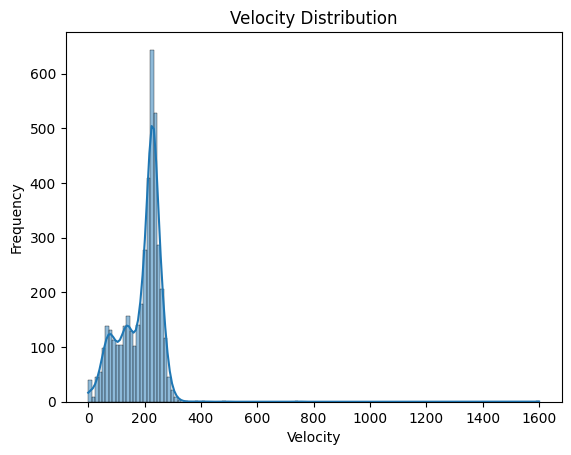

In [90]:
sns.histplot(df['velocity'], kde=True)
plt.title("Velocity Distribution")
plt.xlabel("Velocity")
plt.ylabel("Frequency")
plt.show()

In [91]:
Q1 = df['velocity'].quantile(0.25)
Q3 = df['velocity'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [92]:
#removing outliers
df = df[(df['velocity'] >= lower_bound) & (df['velocity'] <= upper_bound)]

In [93]:
df['velocity'].skew()

np.float64(-0.8331249396385884)

In [94]:
df.shape

(4233, 24)

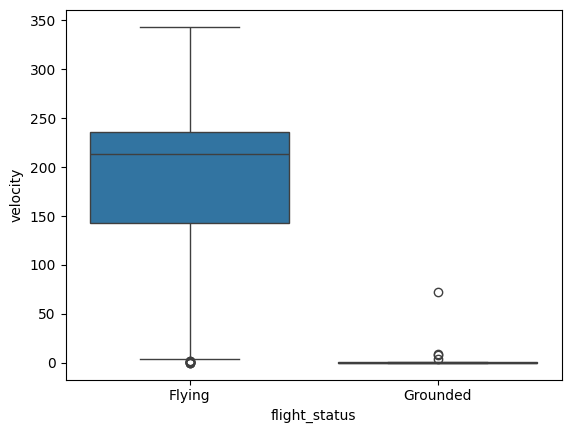

In [95]:
sns.boxplot(x='flight_status', y='velocity', data=df)
plt.show()

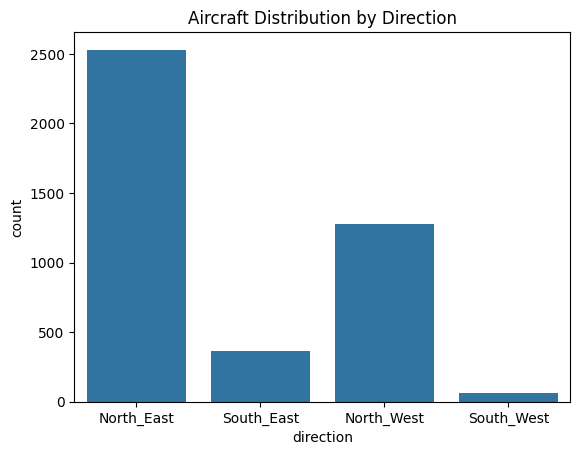

In [96]:
sns.countplot(x='direction', data=df)
plt.title("Aircraft Distribution by Direction")
plt.show()